# Lab11 - Torch Learning

In [3]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt

## Ex. 1) Non-Linear Regression

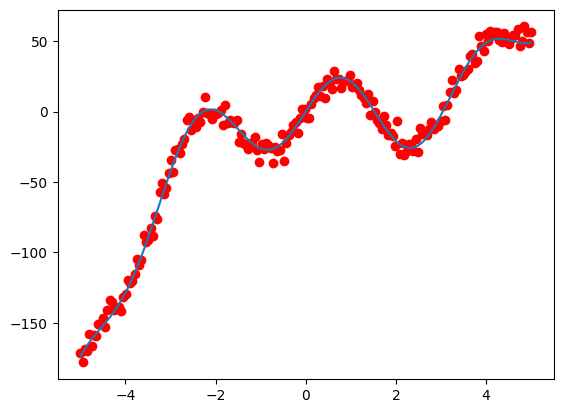

In [43]:
def f(x):
    return x**3 - 2.5 * x**2 + 25 * np.sin(2 * x)

x_true = np.linspace(start=-5, stop=5, num=1000, dtype=np.float32)
y_true = f(x_true)

noise = np.random.normal(loc=0.0, scale=5, size=200).astype(np.float32)
x = np.linspace(start=-5, stop=5, num=200, dtype=np.float32)
y = f(x) + noise

plt.plot(x_true, y_true)
plt.scatter(x, y, color='red')
plt.show()

In [44]:
# Idea:
# - Create a Dataset with the data
# - Build a nn.Module
# - Train it using a Dataloader on the Dataset

class MyDataset(torch.utils.data.Dataset):
    
    def __init__(self, x, y):
        self.x = torch.reshape(x, (len(x), 1))
        self.y = torch.reshape(y, (len(y), 1))
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    
x = torch.from_numpy(x)
y = torch.from_numpy(y)

dataset = MyDataset(x, y)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=25, shuffle=True)

In [62]:
class MLP(nn.Module):
    
    def __init__(self, n_input, n_hidden, n_output):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=n_input, out_features=n_hidden),
            nn.ReLU(),
            nn.Linear(in_features=n_hidden, out_features=n_hidden),
            nn.ReLU(),
            nn.Linear(in_features=n_hidden, out_features=n_output)
        )
        
    def forward(self, x):
        return self.layers(x)
    
model = MLP(
    n_input=1,
    n_hidden=15,
    n_output=1
)

model

MLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=15, bias=True)
    (1): ReLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): ReLU()
    (4): Linear(in_features=15, out_features=1, bias=True)
  )
)

In [63]:
EPOCHS = 10000
LR =  1E-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_function = nn.MSELoss()

for epoch in range(EPOCHS):
    current_loss = 0.0
    
    for i, data in enumerate(dataloader):
        x_batch, y_batch_expected = data
        
        optimizer.zero_grad()
        y_batch = model(x_batch)
        
        loss = loss_function(y_batch, y_batch_expected)
        loss.backward()
        optimizer.step()
        
        current_loss += loss.item()
        
    if (epoch + 1) % 1000 == 0:
        print(f"Loss after {epoch} epochs: {current_loss}")

print("Training process has finished.")

Loss after 999 epochs: 6650.9697265625
Loss after 1999 epochs: 5669.644592285156
Loss after 2999 epochs: 4528.309509277344
Loss after 3999 epochs: 2802.8905334472656
Loss after 4999 epochs: 918.5522079467773
Loss after 5999 epochs: 511.6163673400879
Loss after 6999 epochs: 473.31960678100586
Loss after 7999 epochs: 456.17394638061523
Loss after 8999 epochs: 445.1596450805664
Loss after 9999 epochs: 434.2186279296875
Training process has finished.


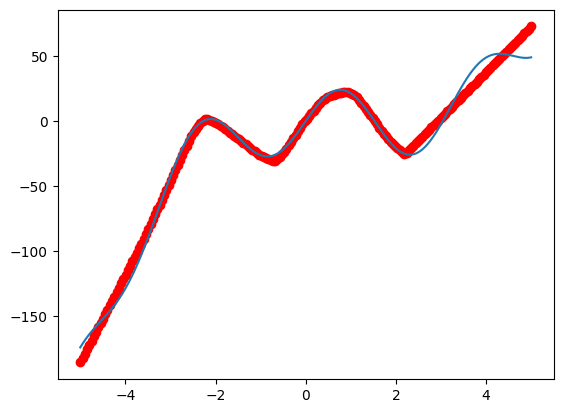

In [65]:
with torch.no_grad():
    y_trained = model(x.unsqueeze(1))
    
plt.plot(x_true, y_true)
plt.scatter(x, y_trained, color='red')
plt.show()

## Ex. 2) Non-Linear Classification

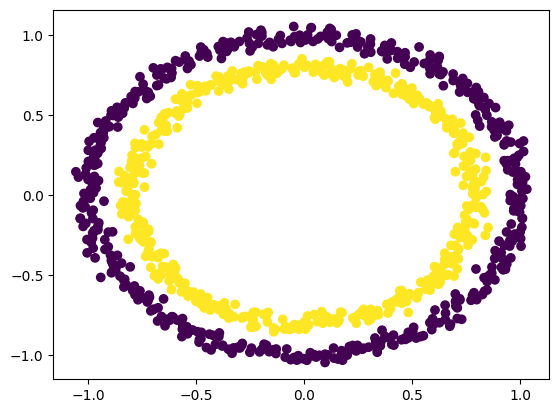

In [80]:
from sklearn.datasets import make_circles

SIZE = 1000

# Create a toy dataset using Scikit-Learn
X, y = make_circles(SIZE, noise=0.03)

plt.scatter(X[:, 0], X[:, 1], c=y)

In [81]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

class MLPClassifier(nn.Module):
    
    def __init__(self, n_input, n_hidden, n_output):
        super(MLPClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=n_input, out_features=n_hidden),
            nn.ReLU(),
            nn.Linear(in_features=n_hidden, out_features=n_hidden),
            nn.ReLU(),
            nn.Linear(in_features=n_hidden, out_features=n_output)
        )
        
    def forward(self, x):
        return self.layers(x)
    

model = MLPClassifier(
    n_input=2,
    n_hidden=10,
    n_output=1 # Binary classification!
)

model
    

MLPClassifier(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [82]:
from sklearn.model_selection import train_test_split

EPOCHS = 20000
LR = 1E-4

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

optimizer = torch.optim.Adam(params=model.parameters(), lr=LR)
loss_function = nn.BCEWithLogitsLoss() # Receives Logits directly (not Probs)

for epoch in range(EPOCHS):
    optimizer.zero_grad()
        
    # Full-Batch learning
    y_train_logits = model(X_train).squeeze()
    loss = loss_function(y_train_logits, y_train)
    
    loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        y_test_logits = model(X_test).squeeze()
        test_loss = loss_function(y_test_logits, y_test)
        
    if epoch % 200 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss} - Test Loss {test_loss}")
        

print("Training has finished")

Epoch: 0 | Train Loss: 0.7106845378875732 - Test Loss 0.6946291327476501
Epoch: 200 | Train Loss: 0.7005148530006409 - Test Loss 0.6896387338638306
Epoch: 400 | Train Loss: 0.6941050887107849 - Test Loss 0.6872024536132812
Epoch: 600 | Train Loss: 0.6890342235565186 - Test Loss 0.685294508934021
Epoch: 800 | Train Loss: 0.681600034236908 - Test Loss 0.6825864911079407
Epoch: 1000 | Train Loss: 0.6728600859642029 - Test Loss 0.6775596737861633
Epoch: 1200 | Train Loss: 0.66363126039505 - Test Loss 0.6715538501739502
Epoch: 1400 | Train Loss: 0.6544287800788879 - Test Loss 0.6642559170722961
Epoch: 1600 | Train Loss: 0.6440309286117554 - Test Loss 0.656141996383667
Epoch: 1800 | Train Loss: 0.6320034265518188 - Test Loss 0.6456702351570129
Epoch: 2000 | Train Loss: 0.6178252696990967 - Test Loss 0.6332095265388489
Epoch: 2200 | Train Loss: 0.6015235185623169 - Test Loss 0.6193113923072815
Epoch: 2400 | Train Loss: 0.5807805061340332 - Test Loss 0.6007610559463501
Epoch: 2600 | Train Loss

(-1.1468963623046875, 1.1550769805908203)

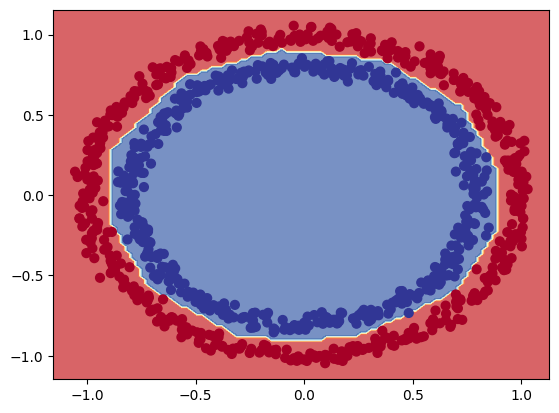

In [83]:
# Fancy plot

model.to("cpu")
X, y = X.to("cpu"), y.to("cpu")

# Setup prediction boundaries and grid
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

# Make features
X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

# Make predictions
model.eval()
with torch.inference_mode():
    y_logits = model(X_to_pred_on)

# Test for multi-class or binary and adjust logits to prediction labels
if len(torch.unique(y)) > 2:
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
else:
    y_pred = torch.round(torch.sigmoid(y_logits))  # binary

# Reshape preds and plot
y_pred = y_pred.reshape(xx.shape).detach().numpy()
plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
